In [1]:
from time import time

import jax.numpy as jnp

from quantum_simulation.jpc_chip import JpcChip
from quantum_simulation.parameters_and_constants import QuantumConstants, SimulationConstants, QuantumParameters

On pose $\hbar = 1$.

**Unités :** 
- Les fréquences et l'Hamiltonien sont données en $\mathrm{MHz}$
- Le temps est donné en  $\mu \mathrm{s} $
- Les $\epsilon$ sont donnés en $ \sqrt{\mathrm{MHz}} $

Dans le référentiel tournant (*Rotating Frame*) l'Hamiltonien du système s'écrit (sans drive) :

$$ H = K_{aa} \left(a^\dagger a \right)^2 + K_{bb} \left(b^\dagger b\right)^2 - K_{ab} \left(a^\dagger a\right) \left( b^\dagger b \right) + g \left( a^\dagger b + a b^\dagger \right) + g_\text{sq} \left( a^\dagger b^\dagger + a b \right) $$

Le *drive* s'exprime dans ce même référentiel :

$$ H_\text{drive} = i \sqrt{\kappa_a}  \left( \epsilon_a^* a - \epsilon_a a^\dagger \right) + i \sqrt{\kappa_b}  \left( \epsilon_b^* b - \epsilon_b b^\dagger \right)   $$

Le *collapse operator* s'exprime :

$$ C = \sqrt{\kappa_a}\; a + \sqrt{\kappa_b}\; b \; \overset{???}{+}\; \sqrt{\kappa_\phi} \;\left( a^\dagger a + b^\dagger b \right) $$


In [2]:
X = jnp.array([-1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1])
#X = jnp.array([1, 1, 1, 1, -1, -1, -1, -1])
params_G = [QuantumParameters(700, 15)]

QP_Dudas = QuantumConstants(
    DIM_A=15,
    DIM_B=15,
    OMEGA_A=1e4,
    OMEGA_B=9 * 1e3,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    EPSILON_A=130,
    EPSILON_B=130,
    DRIVE_DURATION=0.04
)

QP = QP_Dudas

SP = SimulationConstants(10, 150)

chip = JpcChip(QP, SP)



In [3]:
t1 = time()
A = chip.run_simulation(X, params_G)
print(time() - t1)

#c-profile

|██████████| 100.0% ◆ elapsed 01m47s ◆ remaining 0.00ms  


148.91198587417603


C:\Users\ozher\PycharmProjects\Quantum-Learn\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\ozher\PycharmProjects\Quantum-Learn\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


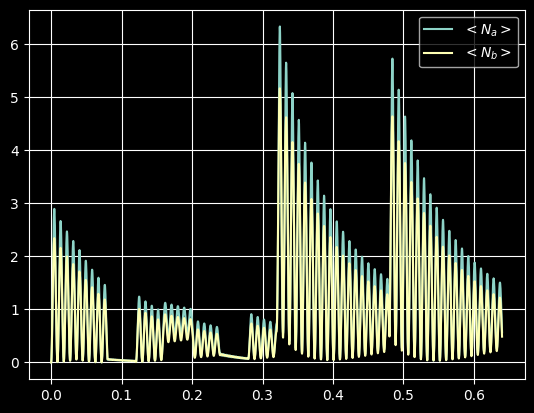

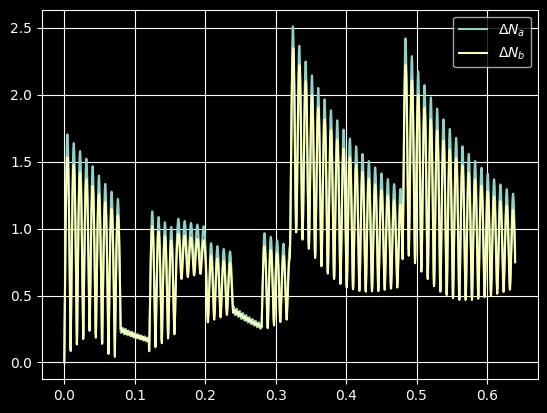

In [4]:
l = A[0].photon_distribution.Plot_Mean_Photon_Number()
l = A[0].photon_distribution.Plot_Sigma_Photon_Number()

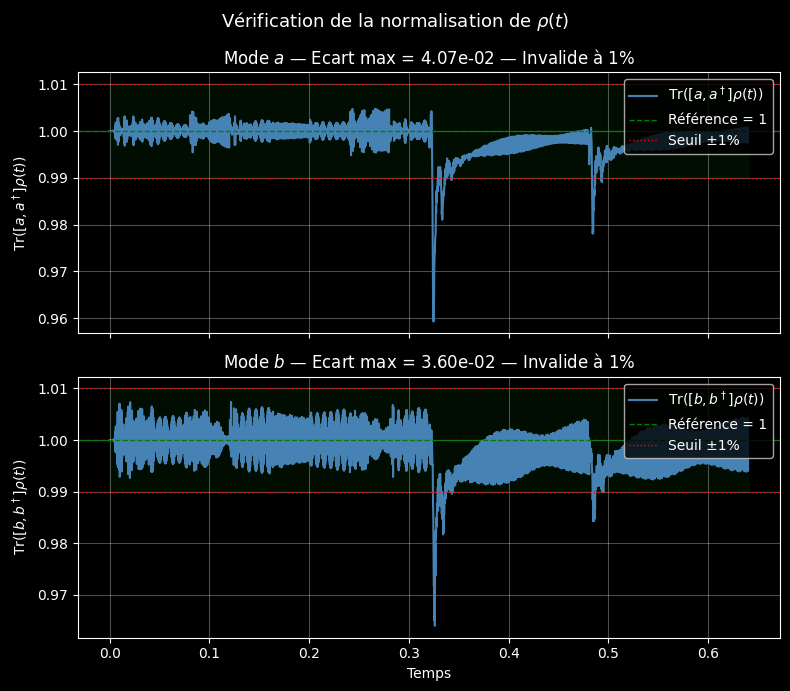

In [5]:
Tr_a, TR_b = A[0].plot_trace_verification()

In [6]:
%matplotlib qt

ImportError: Failed to import any of the following Qt binding modules: PyQt6, PySide6, PyQt5, PySide2

In [ ]:
A[0].photon_distribution.plot_joint_proba()

In [ ]:
A[0].photon_distribution.plot_marginal_proba(mode='a')

In [ ]:
A[0].photon_distribution.plot_marginal_proba(mode='b')

In [ ]:
A[0].photon_distribution.P_b[-1]

Pour un drive constant (sans effet Kerr et sans JRM) :

$$ \langle N_a \rangle \sim \dfrac{4\epsilon_a^2}{\kappa_a}   $$


Pour un drive constant + JRM (sans effet Kerr) :

$$ \langle N_a \rangle \sim \left[  \dfrac{\sqrt{\kappa_a} \epsilon_a + \dfrac{2 (g_\text{conv} + g_\text{sq}) \epsilon_b}{\sqrt{\kappa_b}} }{\dfrac{2(g_\text{conv} + g_\text{sq})^2}{\kappa_b} - \dfrac{\kappa_a}{2}}    \right]^2  $$
